# Gaussian Process Emulator for Heston Implied Volatility

This notebook trains a Gaussian Process emulator for Heston implied volatility using the simulated option surface data.

Workflow:
1. Load `data/simulated_training_data.csv`.
2. Split rows into train and validation sets.
3. Standardize the input features so Heston parameters, strikes, and maturities live on comparable scales.
4. Fit a sklearn `GaussianProcessRegressor` with an RBF kernel and white-noise term.
5. Validate predictions with error metrics and a predicted-vs-true implied volatility plot.


In [1]:
from pathlib import Path
import os
import tempfile

# Keep Matplotlib cache files out of the project and user home directory.
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "hestongp_matplotlib_cache"))
os.environ.setdefault("XDG_CACHE_HOME", str(Path(tempfile.gettempdir()) / "hestongp_matplotlib_cache"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
DATA_PATH = Path("data/simulated_training_data.csv")
OUTPUT_DIR = Path("outputs/gp_emulator_sklearn")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLUMNS = ["v0", "kappa", "theta", "sigma_v", "rho", "K", "T"]
TARGET_COLUMN = "implied_vol"

RANDOM_STATE = 42
VALIDATION_SIZE = 0.20

# Exact GP regression requires a dense covariance matrix. This subset keeps the
# notebook responsive while still training from the 80% training split.
MAX_GP_TRAIN_ROWS = 2500


In [3]:
df = pd.read_csv(DATA_PATH)

required_columns = FEATURE_COLUMNS + [TARGET_COLUMN]
missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Keep only the columns needed for this emulator and remove invalid rows.
df = df[required_columns].replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print(f"Loaded {len(df):,} clean rows")
df.head()


Loaded 51,867 clean rows


,v0,kappa,theta,sigma_v,rho,K,T,implied_vol
0,0.074996,2.1533,0.187783,0.297192,-0.273026,85.0,0.019178,0.291981
1,0.074996,2.1533,0.187783,0.297192,-0.273026,90.0,0.019178,0.286550
2,0.074996,2.1533,0.187783,0.297192,-0.273026,95.0,0.019178,0.281765
3,0.074996,2.1533,0.187783,0.297192,-0.273026,100.0,0.019178,0.277771
4,0.074996,2.1533,0.187783,0.297192,-0.273026,105.0,0.019178,0.274608


In [4]:
X = df[FEATURE_COLUMNS].to_numpy(dtype=float)
y = df[TARGET_COLUMN].to_numpy(dtype=float)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

print(f"Training rows:   {len(X_train):,}")
print(f"Validation rows: {len(X_val):,}")


Training rows:   41,493
Validation rows: 10,374


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Check that the scaled training inputs are centered and comparable in scale.
scaled_summary = pd.DataFrame(
    {
        "mean": X_train_scaled.mean(axis=0),
        "std": X_train_scaled.std(axis=0),
    },
    index=FEATURE_COLUMNS,
)
scaled_summary


,mean,std
v0,2.006806e-14,1.0
kappa,-1.385342e-14,1.0
theta,-6.790595e-15,1.0
sigma_v,2.533065e-14,1.0
rho,-2.552308e-14,1.0
K,-1.125726e-15,1.0
T,-2.130599e-13,1.0


In [6]:
rng = np.random.default_rng(RANDOM_STATE)
if len(X_train_scaled) > MAX_GP_TRAIN_ROWS:
    gp_train_idx = rng.choice(len(X_train_scaled), size=MAX_GP_TRAIN_ROWS, replace=False)
    X_gp_train = X_train_scaled[gp_train_idx]
    y_gp_train = y_train[gp_train_idx]
else:
    X_gp_train = X_train_scaled
    y_gp_train = y_train

print(f"Rows used for exact GP fit: {len(X_gp_train):,}")


Rows used for exact GP fit: 2,500


In [7]:
kernel = RBF(length_scale=np.ones(len(FEATURE_COLUMNS))) + WhiteKernel(noise_level=1e-4)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=5,
    normalize_y=True,
    random_state=RANDOM_STATE,
)

gp.fit(X_gp_train, y_gp_train)
print(gp.kernel_)


RBF(length_scale=[1.12, 4.74, 3.82, 4.16, 2.78, 1.45, 3.77]) + WhiteKernel(noise_level=1.65e-05)


In [8]:
y_pred, y_std = gp.predict(X_val_scaled, return_std=True)

mae = mean_absolute_error(y_val, y_pred)
rmse = mean_squared_error(y_val, y_pred) ** 0.5
r2 = r2_score(y_val, y_pred)
max_abs_error = np.max(np.abs(y_pred - y_val))

metrics = pd.Series(
    {
        "mean_absolute_error": mae,
        "root_mean_squared_error": rmse,
        "max_absolute_error": max_abs_error,
        "r2": r2,
        "train_rows": len(X_train),
        "validation_rows": len(X_val),
        "gp_fit_rows": len(X_gp_train),
    }
)
metrics


mean_absolute_error            0.000760
root_mean_squared_error        0.001918
max_absolute_error             0.049785
r2                             0.999571
train_rows                 41493.000000
validation_rows            10374.000000
gp_fit_rows                 2500.000000
dtype: float64

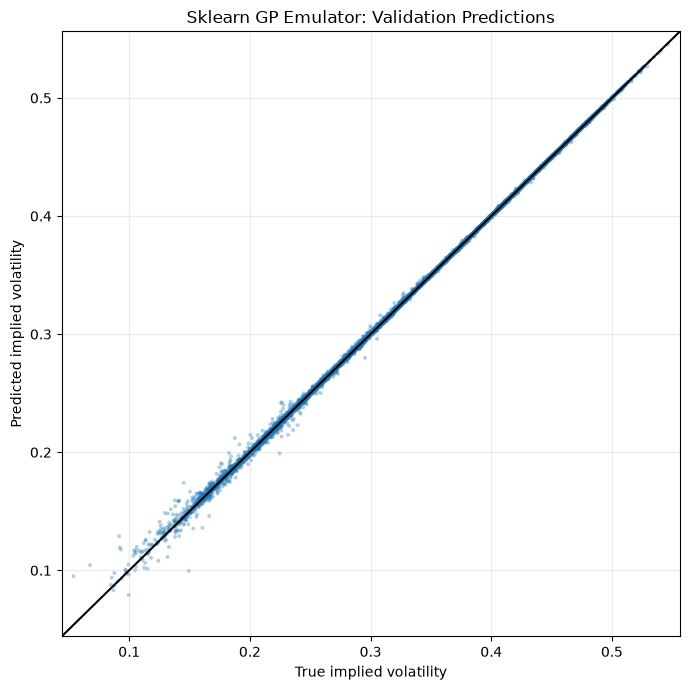

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_val, y_pred, s=8, alpha=0.35, edgecolors="none")

low = min(y_val.min(), y_pred.min())
high = max(y_val.max(), y_pred.max())
pad = 0.02 * (high - low)
ax.plot([low - pad, high + pad], [low - pad, high + pad], color="black", lw=1.5)

ax.set_xlabel("True implied volatility")
ax.set_ylabel("Predicted implied volatility")
ax.set_title("Sklearn GP Emulator: Validation Predictions")
ax.set_xlim(low - pad, high + pad)
ax.set_ylim(low - pad, high + pad)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()


In [10]:
validation_results = pd.DataFrame(
    {
        "true_implied_vol": y_val,
        "predicted_implied_vol": y_pred,
        "predictive_std": y_std,
        "absolute_error": np.abs(y_pred - y_val),
    }
)

validation_results.to_csv(OUTPUT_DIR / "validation_predictions.csv", index=False)
metrics.to_csv(OUTPUT_DIR / "validation_metrics.csv", header=["value"])
fig.savefig(OUTPUT_DIR / "predicted_vs_true_iv.png", dpi=180)

print(f"Saved validation artifacts to {OUTPUT_DIR}")


Saved validation artifacts to outputs/gp_emulator_sklearn
